# Notebook 3: Building the Machine Learning DataSet

Written By Kelly-Marie Yokuda for the BrainStation Capstone Project "Professor Power Index"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project Introduction

To assist early career researchers in establishing their prestige, we demonstrate how machine learning can help early career researchers identify potential co-authors within their network whose added authorship could increase the likelihood of their research being published in highly-cited scientific journals. Specifically, we show that a classification model trained on a database of publications authored by prestigious researchers can successfully classify publications into tiers of scientific journals using co-author metrics alone. 

# Notebook Introduction

To classify citation entries into different tiers, we need to assess the prestige of their publication as well as the prestige of the authors who contributed to the work. Moreover, to train a model that can classify the entries based on the publication metrics of the authors, we must create profiles for each author by analyzing the descriptive statistics of the entries they're cited in. In this notebook, we use the *H index* of each entry to group papers into tiers, which will be our target column. Additionally, we conduct exploratory data analysis on the distribution of metrics for each unique author to construct a dataset for training the machine learning model.

## 3.1 Defining the Target Variable

The objective of **Section 3.1** is to use the combined metrics from `papers_df`, `jour_df` and `profile_df` to define a target variable for classify publications into tiers of scientific journals.

### 3.1.1 Joining Together the DataSets

To have all the metrics we need to build our machine learning data set, we need to join together `papers_df`, `profile_df` and `jour_df`.

Here is `papers_df`

In [2]:
papers_df = pd.read_pickle('output/NB2_papers_df.pkl')

In [3]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15696 entries, 0 to 15695
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      15696 non-null  object 
 1   second_auth     15696 non-null  object 
 2   third_auth      15696 non-null  object 
 3   Cites           15696 non-null  int16  
 4   Title           15696 non-null  object 
 5   Year            15696 non-null  int16  
 6   Source          15696 non-null  object 
 7   GSRank          15696 non-null  int16  
 8   Type            15696 non-null  object 
 9   ECC             15696 non-null  int16  
 10  CitesPerYear    15696 non-null  float16
 11  CitesPerAuthor  15696 non-null  int16  
 12  AuthorCount     15696 non-null  int8   
 13  profile_id      15696 non-null  int16  
dtypes: float16(1), int16(6), int8(1), object(6)
memory usage: 965.8+ KB


Here is `profile_df`

In [4]:
profile_df = pd.read_pickle('output/NB2_profile_df.pkl')

In [5]:
profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              616 non-null    int16 
 1   Query           616 non-null    object
 2   profile_author  616 non-null    object
dtypes: int16(1), object(2)
memory usage: 11.0+ KB


Now let's join the `papers_df` and `profile_df` together to make the data set `join_df`

In [6]:
join_df = pd.merge(left = papers_df, right = profile_df[['id', 'profile_author']], left_on = 'profile_id', right_on = 'id')

In [7]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15696 entries, 0 to 15695
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      15696 non-null  object 
 1   second_auth     15696 non-null  object 
 2   third_auth      15696 non-null  object 
 3   Cites           15696 non-null  int16  
 4   Title           15696 non-null  object 
 5   Year            15696 non-null  int16  
 6   Source          15696 non-null  object 
 7   GSRank          15696 non-null  int16  
 8   Type            15696 non-null  object 
 9   ECC             15696 non-null  int16  
 10  CitesPerYear    15696 non-null  float16
 11  CitesPerAuthor  15696 non-null  int16  
 12  AuthorCount     15696 non-null  int8   
 13  profile_id      15696 non-null  int16  
 14  id              15696 non-null  int16  
 15  profile_author  15696 non-null  object 
dtypes: float16(1), int16(7), int8(1), object(7)
memory usage: 1.1+ MB


We can remove `profile_id` and `id` from this data set.

In [8]:
join_df = join_df.drop(['profile_id', 'id'], axis = 1)

In [9]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15696 entries, 0 to 15695
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      15696 non-null  object 
 1   second_auth     15696 non-null  object 
 2   third_auth      15696 non-null  object 
 3   Cites           15696 non-null  int16  
 4   Title           15696 non-null  object 
 5   Year            15696 non-null  int16  
 6   Source          15696 non-null  object 
 7   GSRank          15696 non-null  int16  
 8   Type            15696 non-null  object 
 9   ECC             15696 non-null  int16  
 10  CitesPerYear    15696 non-null  float16
 11  CitesPerAuthor  15696 non-null  int16  
 12  AuthorCount     15696 non-null  int8   
 13  profile_author  15696 non-null  object 
dtypes: float16(1), int16(5), int8(1), object(7)
memory usage: 1.0+ MB


Here is `jour_df`

In [10]:
jour_df = pd.read_pickle('output/NB1_V2.1_jour_df.pkl')

In [11]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6280 entries, 0 to 6279
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    6280 non-null   object 
 1   Type     6280 non-null   object 
 2   SJR      6202 non-null   float16
 3   H index  6280 non-null   float64
 4   Country  6280 non-null   object 
 5   Region   6280 non-null   object 
dtypes: float16(1), float64(1), object(4)
memory usage: 257.7+ KB


Now let's inter join `jour_df` with `join_df` to make a new `join_df`.

In [12]:
join_df = pd.merge(left = join_df, right = jour_df, left_on = 'Source', right_on = 'Title')

Here is the new `join_df`

In [13]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      14382 non-null  object 
 1   second_auth     14382 non-null  object 
 2   third_auth      14382 non-null  object 
 3   Cites           14382 non-null  int16  
 4   Title_x         14382 non-null  object 
 5   Year            14382 non-null  int16  
 6   Source          14382 non-null  object 
 7   GSRank          14382 non-null  int16  
 8   Type_x          14382 non-null  object 
 9   ECC             14382 non-null  int16  
 10  CitesPerYear    14382 non-null  float16
 11  CitesPerAuthor  14382 non-null  int16  
 12  AuthorCount     14382 non-null  int8   
 13  profile_author  14382 non-null  object 
 14  Title_y         14382 non-null  object 
 15  Type_y          14382 non-null  object 
 16  SJR             14382 non-null  float16
 17  H index         14382 non-null 

We can remove `Title_y` (redundant to `Source`) and `Title_x` (only has one unique value) and rename `Title_x` to `EntryTitle` and `Type_y` to `PubType`.

In [14]:
join_df = join_df.drop(['Title_y', 'Type_x'], axis = 1)

In [15]:
join_df.columns = ['first_auth', 'second_auth', 'third_auth', 'Cites', 'EntryTitle', 'Year',
       'Source', 'GSRank', 'ECC', 'CitesPerYear', 'CitesPerAuthor',
       'AuthorCount', 'profile_author', 'PubType', 'SJR', 'H index', 'Country',
       'Region']

Here is the new `join_df`

In [16]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      14382 non-null  object 
 1   second_auth     14382 non-null  object 
 2   third_auth      14382 non-null  object 
 3   Cites           14382 non-null  int16  
 4   EntryTitle      14382 non-null  object 
 5   Year            14382 non-null  int16  
 6   Source          14382 non-null  object 
 7   GSRank          14382 non-null  int16  
 8   ECC             14382 non-null  int16  
 9   CitesPerYear    14382 non-null  float16
 10  CitesPerAuthor  14382 non-null  int16  
 11  AuthorCount     14382 non-null  int8   
 12  profile_author  14382 non-null  object 
 13  PubType         14382 non-null  object 
 14  SJR             14382 non-null  float16
 15  H index         14382 non-null  float64
 16  Country         14382 non-null  object 
 17  Region          14382 non-null 

### 3.1.2 Building the Target Variable

Our task is to categorize each entry into publication tiers according to their level of prestige. To achieve this, we will assign each entry to a tier based on its `H index`, which is a metric that takes into account both the number of highly cited papers and the number of citations a publication source has received. This metric is an appropriate choice for our dataset since it provides a descriptive measure of the impact and influence of a publication source.

First, we will aggregate the h indexes by rounding them up to the nearest 10 to achieve a normal distribution of h indexes.

In [17]:
# Rounding H-indexes to 10 
join_df['H index'] = join_df['H index'].apply(lambda x: round(x/10) * 10)

(array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50]),
 [Text(0, 0, '1280'),
  Text(5, 0, '580'),
  Text(10, 0, '450'),
  Text(15, 0, '380'),
  Text(20, 0, '330'),
  Text(25, 0, '280'),
  Text(30, 0, '230'),
  Text(35, 0, '180'),
  Text(40, 0, '130'),
  Text(45, 0, '80'),
  Text(50, 0, '30')])

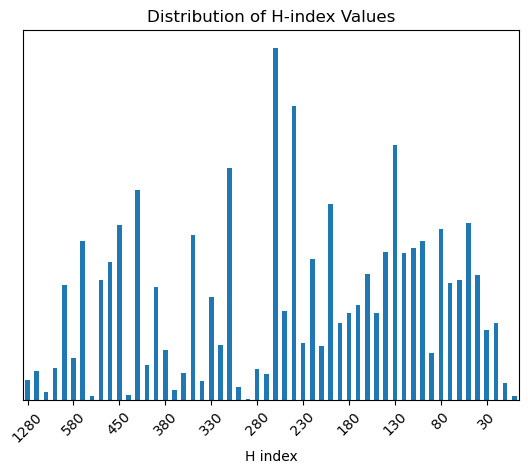

In [18]:
# Plotting the results
ax = join_df['H index'].value_counts(normalize = True).sort_index(ascending= False).plot(kind = 'bar')

# Set title
ax.set_title("Distribution of H-index Values")

# Remove y-axis labels
ax.set_yticks([])

# Set x-axis labels to show only every 20th value
ax.set_xticks(range(0, len(join_df['H index'].value_counts()), 5))

# Rotate x-axis labels for better visibility, if necessary
plt.xticks(rotation=45)

Here we see that rounding the H-index values to the nearest 10 helps normalize their distribution.


Next, we will sort the entries into tiers based on their H-index values. This code sorts entries in the `join_df` DataFrame by `H index` and `CitesPerYear` in descending order. It then assigns these entries into three tiers, ensuring each tier contains roughly one-third of the total entries. The maximum number of entries per tier is determined by dividing the total number of entries by 3. A loop iterates through the sorted entries, assigns them to tiers, and stores the tier, `H index`, and `EntryTitle` in a dictionary. Once all entries are processed, the dictionary is converted into a new DataFrame `pub_df`, which organizes the data by publication tier.

In [19]:
# Convert the problematic columns to float32 to navigate data type issues
join_df['H index'] = join_df['H index'].astype('float32')
join_df['CitesPerYear'] = join_df['CitesPerYear'].astype('float32')

# 1. Sort entries by H index
sort_df = join_df.sort_values(['H index', 'CitesPerYear'], ascending=[False, False])

# 2. Defining the maximum number of entries per tier
tier_member_max = int(sort_df.shape[0]/3)

# 3. Defining a Dictionary to Store the Values
pub_dic = {'PubTier': [], 'H index': [], 'EntryTitle':[]}

# 4. Looping over entries to sort them into tiers
counter = 0 # tracks the number of papers in each tier
tier = 1
for i in sort_df.index:
    
    # If the counter is larger than the max allowed number, and the tier is not 3 (let overflow into tier 3)
    if counter > tier_member_max and tier !=3:
        # Increase the tier and reset the counter
        tier = tier + 1
        counter = 0
        
    pub_dic['PubTier'].append(tier)
    pub_dic['H index'].append(sort_df.loc[i, 'H index'])
    pub_dic['EntryTitle'].append(sort_df.loc[i, 'EntryTitle'])
        
    counter = counter + 1

pub_df = pd.DataFrame(pub_dic)

Let's check to be sure the number of values in `PubTier` is equal to the number of rows in `join_df`

In [20]:
pub_df['PubTier'].shape[0] == join_df.shape[0]

True

This is true, therefore each entry was accounted for. Let's check the distribution of entries in each tier.

In [21]:
pub_df['PubTier'].value_counts(normalize = True)

PubTier
1    0.333403
2    0.333403
3    0.333194
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Distribution (Counts) of Publictaion\nH-Indexes for Each Tier')

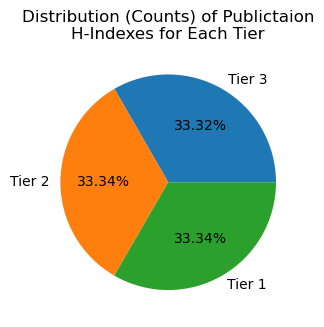

In [22]:
fig = plt.figure(figsize = (3.5, 3.5))
ax = fig.subplots(1,1)

# Converting value counts to data frame to use seaborn plotting
val_cts_df = pub_df['PubTier'].value_counts(normalize = True).reset_index().sort_values('PubTier', ascending = False)
val_cts_df['index'] = val_cts_df['PubTier'].apply(lambda x: f'Tier {x}')

plt.pie(val_cts_df['proportion'], labels=val_cts_df['index'], autopct='%.2f%%')  

plt.title('Distribution (Counts) of Publictaion\nH-Indexes for Each Tier')

# Optional: save the figure
#fig.savefig(r'slides/NB3_1.png', transparent = True, dpi = 800)

This distribution suggests that the entries have been divided very evenly across the three tiers, with only a negligible difference between them (less than 0.01% difference in Tier 3). The nearly equal distribution indicates a balanced grouping approach was used when assigning entries to tiers. 

Let's examine the variation in the spread of each tier. Analyzing the variation in the distribution of H-indexes across tiers will help us verify the accuracy of sorting the publications into distinct tiers based on their H-index.

In [23]:
group_df = pub_df.groupby('PubTier')['H index'].apply(list)

# Find the list with the largest size
max_size = 0
for tier_list in group_df.values:
    if len(tier_list) > max_size:
        max_size = len(tier_list)

# Initiate an array based on the maximum size
tier_arr = np.zeros([max_size, 3])

# Set as array of NaNs
tier_arr[:,:] = np.nan

# Add values to array
for i, tier_list in enumerate(group_df.values):
    for j in range(max_size):
        if j < len(tier_list):
            tier_arr[j, i] = tier_list[j] 

# Distibute into df
tier_df = pd.DataFrame(tier_arr, columns = ['Tier 1', 'Tier 2', 'Tier 3'])

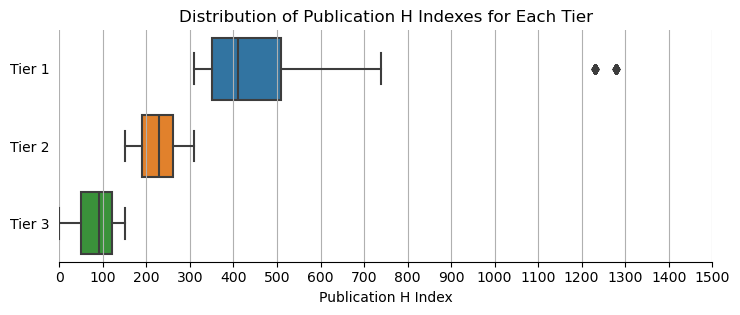

In [24]:
# Plotting the results
fig = plt.figure(figsize=(7.5, 3.25))
ax = fig.subplots(1,1)
boxplot = sns.boxplot(data=tier_df, orient='h', ax=ax)

# Customize labels and title
plt.xlabel('Publication H Index', font='DejaVu Sans')
plt.title('Distribution of Publication H Indexes for Each Tier')

# Remove unnecessary spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove y-axis ticks
ax.tick_params(axis="y", left=False)

# Set x-axis limits and ticks
ax.set_xlim([0, 1400])
ax.set_xticks(ticks=np.arange(0, 1600, 100))

# Add vertical grid lines every 100 values
ax.grid(True, axis='x', which='both')

fig.tight_layout()

# Optional: save the figure
# fig.savefig(r'slides/NB3_2.png', transparent=True, dpi=800)

In [25]:
des_df = tier_df.describe()
(des_df.loc['75%', :] - des_df.loc['25%', :]).reset_index(name = 'IQR')

,index,IQR
0,Tier 1,160.0
1,Tier 2,70.0
2,Tier 3,70.0


Based on the distributions, we have the following insights:

- The **mean** value decreases for each subsequent tier, as well as the **standard deviation**, and **median** values. These results suggest that the H indexes increase *on average* as the tier increase, as well as suggesting samples in the lower classification tier have a less diverse range of H indexes than the higher tier. 
- The minimum and maximum values for each tier do not overlap with each other, further suggesting that the H-indexes are categorized in the correct tier.

Let's perform a left join between `join_df` and `PubTier` using the publication's entry title. This will ensure that each publication entry includes its corresponding rounded H-index and associated Publication Tier.

In [26]:
join_df = pd.merge(left = join_df, right = pub_df, left_on = 'EntryTitle', right_on = 'EntryTitle')

Here is information about the new `join_df`.

In [27]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      14382 non-null  object 
 1   second_auth     14382 non-null  object 
 2   third_auth      14382 non-null  object 
 3   Cites           14382 non-null  int16  
 4   EntryTitle      14382 non-null  object 
 5   Year            14382 non-null  int16  
 6   Source          14382 non-null  object 
 7   GSRank          14382 non-null  int16  
 8   ECC             14382 non-null  int16  
 9   CitesPerYear    14382 non-null  float32
 10  CitesPerAuthor  14382 non-null  int16  
 11  AuthorCount     14382 non-null  int8   
 12  profile_author  14382 non-null  object 
 13  PubType         14382 non-null  object 
 14  SJR             14382 non-null  float16
 15  H index_x       14382 non-null  float32
 16  Country         14382 non-null  object 
 17  Region          14382 non-null 

Since the H index's were used to group the entries into tiers, they're essentially redundant top the target variable. Let's remove them from `join_df`. 

In [28]:
join_df = join_df.drop(['H index_x', 'H index_y'], axis = 1)

Here are the resulting columns.

In [29]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      14382 non-null  object 
 1   second_auth     14382 non-null  object 
 2   third_auth      14382 non-null  object 
 3   Cites           14382 non-null  int16  
 4   EntryTitle      14382 non-null  object 
 5   Year            14382 non-null  int16  
 6   Source          14382 non-null  object 
 7   GSRank          14382 non-null  int16  
 8   ECC             14382 non-null  int16  
 9   CitesPerYear    14382 non-null  float32
 10  CitesPerAuthor  14382 non-null  int16  
 11  AuthorCount     14382 non-null  int8   
 12  profile_author  14382 non-null  object 
 13  PubType         14382 non-null  object 
 14  SJR             14382 non-null  float16
 15  Country         14382 non-null  object 
 16  Region          14382 non-null  object 
 17  PubTier         14382 non-null 

Now that each publication is labeled with its Publication Tier, we can observe the distribution of publication counts across the different tiers.

In [30]:
join_df.groupby('PubTier')['Source'].nunique().reset_index(name = 'Number of Publications Titles')

,PubTier,Number of Publications Titles
0,1,40
1,2,169
2,3,639


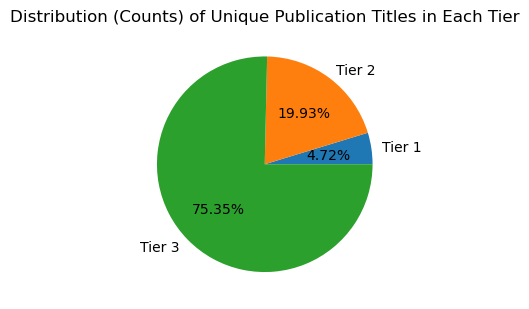

In [31]:
fig = plt.figure(figsize = (3.5, 3.5))

# Converting value counts to data frame to use seaborn plotting
val_cts_df = join_df.groupby('PubTier')['Source'].nunique().reset_index(name = 'Titles (ct)').sort_values('PubTier', ascending = True)
val_cts_df['index'] = val_cts_df['PubTier'].apply(lambda x: f'Tier {x}')

plt.pie(val_cts_df['Titles (ct)'], labels=val_cts_df['index'], autopct='%.2f%%')  

plt.title('Distribution (Counts) of Unique Publication Titles in Each Tier')

# Optional: save the figure
fig.savefig(r'slides/NB3_2.1.png', transparent = True, dpi = 800)

From the distribution of unique publication entries across the tiers, we observe that the majority (over 75%) of entries fall into Tier 3, while a smaller proportion is unevenly distributed across Tier 2 (19.93%) and Tier 1 (4.72%). This uneven distribution suggests that Tier 3 publications dominate the dataset. If the tier distribution were to be used as a target variable in a model, the imbalance could pose challenges, potentially leading to bias in favor of Tier 3. Proper handling of this class imbalance, such as resampling or using weighted metrics, would be crucial for accurate modeling.

To conclude, we demonstrated that the entries in `join_df` can be classified into equally balanced tiers based on h indexes. However, we also warned that imbalance in those classes' distribution of these tiers could lead to classification problems in the future.

## 3.2 Expand Entries 

The aim of **Section 3.2** is to create a descriptive profile for each author by utilizing the descriptive statiscs associated with each of their entries in the dataset. In other words, the goal is to convert a DataFrame of research papers where each row represents a paper  with multiple authors (`join_df`) into a DataFrame where each row represents an individual author, while retaining the associated metadata from the original row, defined as `exapand_df1`. The author’s name and their rank in the author list are included in the new DataFrame, and each paper's metadata is repeated for every author associated with it. See an example below.


|Name |Title| ...|
|-----|--------|----|
|d shi|low trap-state density and| ...|
|v adinolfi	 |low trap-state density and| ...|
|r comin |low trap-state density and| ...|
|h tan	| efficient and stable solution-| ...|

In [32]:
def make_df(row):
    '''
    
    Parameters:
    ----------
    row: pandas.Series 
        a Pandas Series that is a single row in the larger papers_df data frame. This row should contain
    information about the paper, including the columns 'first_auth', 'second_auth', 'third_auth'.
    
    Return:
    -------
    ret_df: pandas.DataFrame 
        a new data frame that has repeated information about each paper for each author. 
        It also has new columns 'AuthorName' and 'AuthorRank'
    
    '''
    
    # NumpPy Array of the author names
    auth_list = np.unique(row[['first_auth', 'second_auth', 'third_auth', 'profile_author']].values)
    
    # Series of values exlcuding the first, second and third author columns
    new_ser = row.drop(['first_auth', 'second_auth', 'third_auth', 'profile_author'])
    
    # Initiate a New Data Fame
    ret_df = pd.DataFrame()
    
    # Adding new rows to the data frame for each author in the paper
    for i in range(auth_list.shape[0]):
        auth_ser = pd.Series({'AuthorName': auth_list[i], 'AuthorRank': i+1})
        concat_ser = pd.concat([auth_ser, new_ser])
        
        concat_df = pd.DataFrame([concat_ser])
        ret_df = pd.concat([ret_df, concat_df], axis = 0)
    
    return ret_df

In [33]:
from tqdm.notebook import tqdm 

# Initiate DataFrame
expand_df1 = pd.DataFrame()

# Adding new data frames (this takes about 4-5 minutes)
# Using a for loop instead of .apply() to be able to use the tqdm module to track the progress
for i in tqdm(range(join_df.shape[0])):
    row = join_df.loc[i, :]
    
    # Make a new set of dataframe
    ret_df = make_df(row)
     
    # Add to new df
    expand_df1 = pd.concat([expand_df1, ret_df], axis = 0)

  0%|          | 0/14382 [00:00<?, ?it/s]

In [34]:
expand_df1 = expand_df1.reset_index(drop = True)

Here is the `expand_df1`

In [35]:
expand_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57203 entries, 0 to 57202
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AuthorName      57203 non-null  object 
 1   AuthorRank      57203 non-null  int64  
 2   Cites           57203 non-null  int16  
 3   EntryTitle      57203 non-null  object 
 4   Year            57203 non-null  int16  
 5   Source          57203 non-null  object 
 6   GSRank          57203 non-null  int16  
 7   ECC             57203 non-null  int16  
 8   CitesPerYear    57203 non-null  float32
 9   CitesPerAuthor  57203 non-null  int16  
 10  AuthorCount     57203 non-null  int8   
 11  PubType         57203 non-null  object 
 12  SJR             57203 non-null  float16
 13  Country         57203 non-null  object 
 14  Region          57203 non-null  object 
 15  PubTier         57203 non-null  int64  
dtypes: float16(1), float32(1), int16(5), int64(2), int8(1), object(6)
memory usa

Here, we added a new column `AuthorRank` which refers to the original placement of the author (first, second, third, profile). We can also add a new descritive column titled `Author_Hindex` which describes the H-index of each individual author based on the dataset. These H-index values will be merged onto the exisiting `expand_df1`, resulting in `expand_df2`.

In [2]:
def calculate_hindex(group):
    
    """
    Calculates the H-index for a given group of publications based on their citation counts.

    Parameters:
    -----------
    group: pandas.DataFrame or pandas.Series
        A group containing a 'Cites' column with citation counts for each publication.
    
    Returns:
    --------
    h_index: int
        The calculated H-index, representing the largest number of papers with at least that number of citations.

    Example:
    --------
    For citation counts [10, 8, 5, 4, 3], the H-index would be 4.
    """
    
    # An arr of the citations
    citations = group['Cites'].values.tolist()
    
    n = len(citations)
    citations.sort(reverse=True)
    h_index = 0
    
    for i in range(n):
        if citations[i] >= i+1:
            h_index = i+1
        else:
            break
    
    return h_index

In [101]:
# Calculate H-index as new series, group by author
h_idx_series = expand_df1.groupby('AuthorName').apply(calculate_hindex, include_groups=False)

# Convert to DataFrame to Rename Columns
h_idx_df = h_idx_series.reset_index(drop = False).rename(columns={0: 'Author_Hindex'})

# Join onto expand_df1 on 'AuthorName'
expand_df2 = pd.merge(left = expand_df1, right = h_idx_df, on = 'AuthorName')

### 3.2.1 Data Integrity Checks
Let's check for nulls in the new `expand_df2`

In [103]:
expand_df2.isna().sum()

AuthorName             0
AuthorRank             0
Cites                  0
EntryTitle             0
Year                   0
Source                 0
GSRank                 0
ECC                    0
CitesPerYear           0
CitesPerAuthor         0
AuthorCount            0
PubType                0
SJR                    0
Country                0
Region                 0
PubTier                0
Author_Hindex_x    41900
Author_Hindex_y        0
dtype: int64

There are no null values introduced. Let's check for duplicate rows to acess uniqueness.

In [104]:
# Check for any duplicate rows
expand_df2.duplicated().any()  # Returns True if there are any duplicate rows

False

In [37]:
# Pickle the dataset for faster access
expand_df2.to_pickle('expand_df.pkl')

### 3.2.2 Feature Engineering

Now that we have the new DataFrame, building a profile for each author becomes easier. We will achieve this by aggregating the numeric *feature* columns, while excluding the object-type columns. Ideally, the object columns could be converted into numeric data types to serve as additional features, but for now, we will focus only on the existing numeric columns.

The code below prepares for author profiling by isolating relevant numeric features (e.g., citation counts, H-indexes) and excluding non-numeric columns. This prepares the entries to be aggregated by author, allowing us to form profiles based on their overall contributions, such as total citations or average impact.

In [3]:
# Use pickled expand_df
expand_df1 = pd.read_pickle('expand_df.pkl')

sub_df = pd.concat([expand_df1.loc[:, 'AuthorName'], expand_df1.select_dtypes('number').drop('PubTier', axis = 1)], axis = 1)

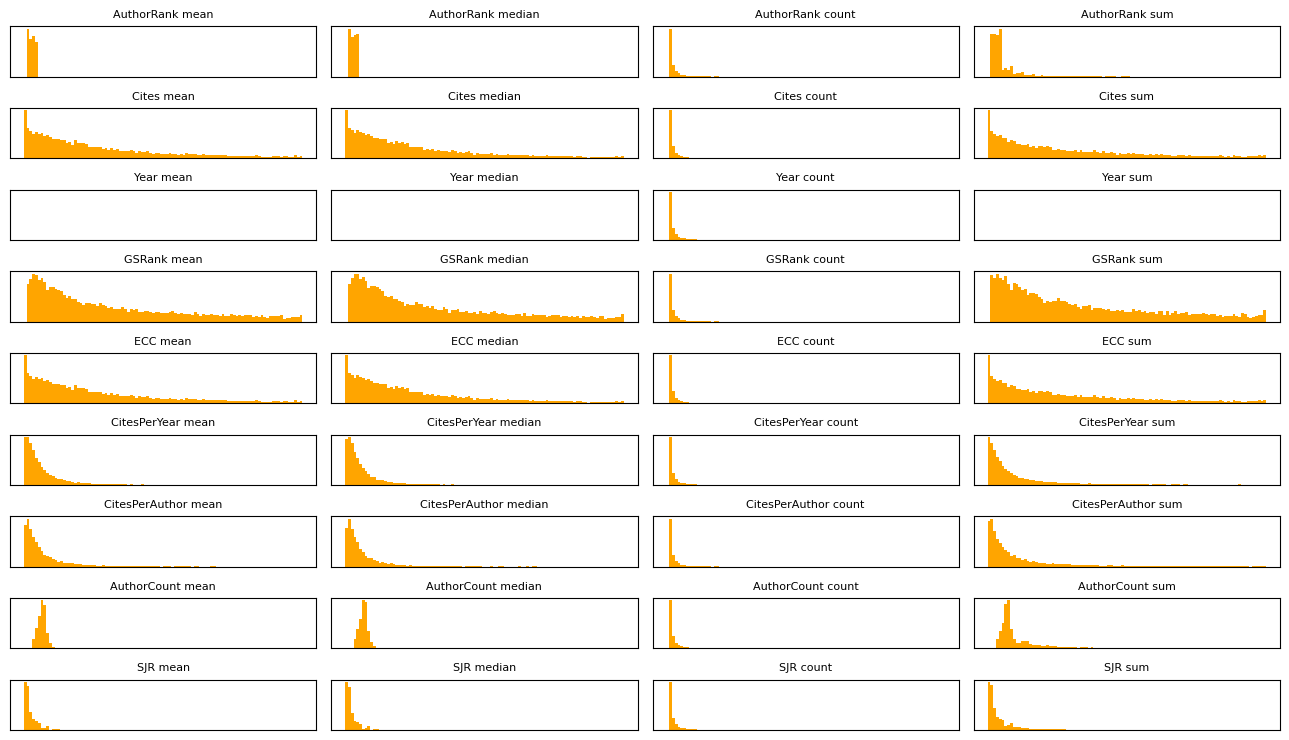

In [33]:
# Aggregate Data
grouped_df = sub_df.groupby('AuthorName').agg(['mean', 'median', 'count', 'sum'])

# Identify columns 
level1_cols = sub_df.columns[1:]
level2_cols = ['mean', 'median', 'count', 'sum']

# Plot the histograms
fig = plt.figure(figsize = (13, 7.5))
axes = fig.subplots(len(level1_cols), len(level2_cols))

i = 0 
for (row, col), ax in np.ndenumerate(axes):
    
    l1 = level1_cols[row]
    l2 = level2_cols[col]
    
    ax.hist(grouped_df[(l1, l2)], bins=100, range=(0, 100), color='orange')
    ax.set_title(f'{l1} {l2}', fontsize = 8)
    ax.set_xticks([],[])
    ax.set_yticks([],[])
    
    i += 1
    
fig.tight_layout()

# Optional: save the figure
#fig.savefig('slides/NB3_2.png', transparent = True, dpi = 800)

The distributions above show the results of the author profiling and example aggregations. For most features, the mean and median exhibit a similar right-skewed distribution, just like the count and sum. However, there are exceptions: `AuthorCount` and `AuthorRank`, where the mean and median appear to have a more *normal* distribution, with the median providing a particularly normal distribution for `AuthorCount`. Additionally, `Year` only shows a distribution for the count. Let's apply a log transformation to rescale the values and see if the distributions change.

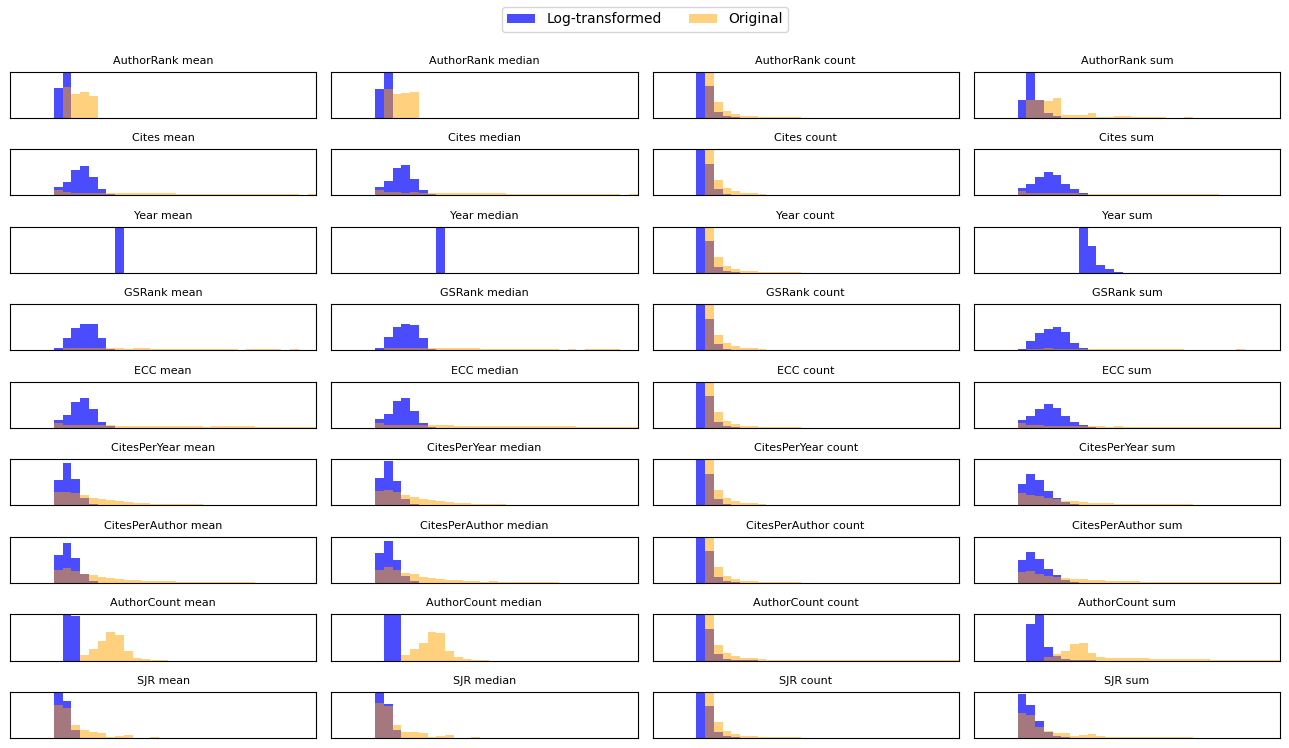

In [31]:
# Identify columns 
level1_cols = sub_df.columns[1:]
level2_cols = ['mean', 'median', 'count', 'sum']

# Plot the histograms
fig = plt.figure(figsize=(13, 7.5))
axes = fig.subplots(len(level1_cols), len(level2_cols))

i = 0 
for (row, col), ax in np.ndenumerate(axes):
    
    l1 = level1_cols[row]
    l2 = level2_cols[col]
    
    values_before = grouped_df[(l1, l2)]  # Data without log transformation
    values_after = grouped_df[(l1, l2)].apply(lambda x: np.log1p(x))  # Applying log transformation

    # Plot histograms with labels (labels only need to be set once, but appear here for flexibility)
    ax.hist(values_after, bins=100, range=(0, 100), label='Log-transformed', color='blue', alpha=0.7)
    ax.hist(values_before, bins=100, range=(0, 100), label='Original', color='orange', alpha=0.5)

    ax.set_title(f'{l1} {l2}', fontsize=8)
    ax.set_xticks([], [])
    ax.set_yticks([], [])
    ax.set_xlim([-5.0, 30])
    ax.set_ylim([0, 6800])
    
    i += 1

# Add a single legend for the entire figure, outside the axes
fig.legend(labels=['Log-transformed', 'Original'], loc='upper center', ncol=2, fontsize=10)

fig.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the legend


The histograms visualized above demonstrate the distribution of various author-related metrics, both before and after log transformation. Many of the original metrics, such as `Cites`, `CitesPerYear`, `CitesPerAuthor`, and `AuthorCount`, exhibit strong right-skewness, indicating that a few authors have significantly higher values than most. The log transformation effectively reduces this skew, making the data more normally distributed, particularly for citation-related features. Metrics like `AuthorRank` and `AuthorCount` show relatively normal distributions even without transformation, suggesting less variability in those areas. Overall, the log transformation makes the data more manageable and better suited for analysis by reducing the impact of extreme outliers.

In contrast, the `Year` and `SJR` metrics do not show much variation in their mean and median, suggesting that most publications were released around the same time and have similar `SJR` values, respectively. `SJR` (SCImago Journal Rank) reflects the scientific impact of journals, and its limited variation here suggests that the papers were published in journals of relatively similar rank. Additionally, the right-skewed distribution of `Year` both before and after log transformation suggests that a small number of more recent publications are driving this skew. This indicates that while the majority of the publications are concentrated in a central time period, more recent publications, though fewer in number, may represent a growing trend over time. 

Given that the `Year` metric does not exhibit a normal distribution after transformation and shows limited variation, it may not be a useful feature for further analysis and should be considered for removal. The same logic can be applied to other features that don't show enough variation or contribute meaningfully to predictive , such as `SJR`.

Overall, chosen metrics are as follows:

*Median (Log-Transformed)*
- `Cites`
- `GSRank`
- `ECC`
- `CitesPerYear`
- `CitesPerAuthor`

*Median (Original)*
- `AuthorCount`
- `AuthorRank`

In [36]:
# Seperating metrics based on their respective transformation

# Original
level1_cols_og = ['AuthorRank', 'AuthorCount']

# Log-Transformed
level1_cols_trans = ['Cites',  'GSRank', 'ECC', 'CitesPerYear',
       'CitesPerAuthor']

In [64]:
# Use pd.IndexSlice for slicing multi-level columns
idx = pd.IndexSlice

# Select all Level 1 columns and 'median' from Level 2
grouped_df2 = grouped_df.loc[:, idx[:, 'median']].copy()

# Drop Metrics not in use
grouped_df2 = grouped_df2.drop(['SJR', 'Year'], axis = 1)

# Reduce hirarchy of columns
grouped_df2.columns = ['_'.join(col).strip() for col in grouped_df2.columns]

# Reset index so `AuthorName` becomes its own column
grouped_df2 = grouped_df2.reset_index(drop = False)

Here is the resulting DataFrame.

In [65]:
grouped_df2.head()

,AuthorName,AuthorRank_median,Cites_median,GSRank_median,ECC_median,CitesPerYear_median,CitesPerAuthor_median,AuthorCount_median
0,a a petrov,1.0,3.0,53.0,3.0,1.000000,1.0,5.0
1,a abbasi,1.0,54.0,8.0,54.0,7.710938,11.0,5.0
2,a abdollahi,1.0,150.0,52.0,150.0,30.000000,38.0,4.0
3,a abherve,1.0,33.0,44.0,33.0,6.601562,6.0,6.0
4,a ablat,1.0,18.0,256.0,18.0,3.599609,2.0,8.0


Now that we have a DataFrame with a profile of each author, we can aggregate those metrics 

In [136]:
gb_full2.isna().sum()

AuthorName            0
Median_AuthorRank     0
Median_Cites          0
Median_Year           0
Median_GSRank         0
Median_AuthorCount    0
Author_Hindex         0
dtype: int64

<AxesSubplot:>

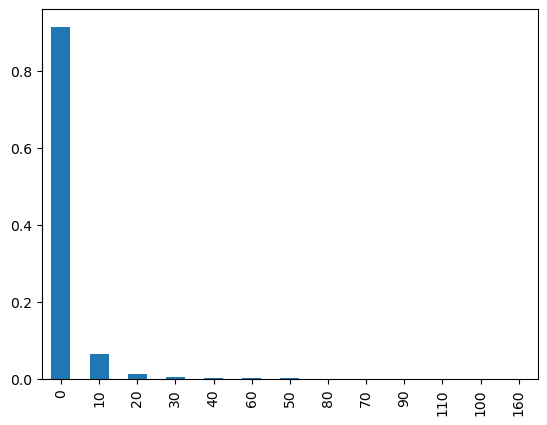

In [153]:
hindex_ser['Author_Hindex'].apply(round2ten).value_counts(normalize = True).plot(kind = 'bar')

In [ ]:
grouped_df = hindex_ser.groupby('AuthorName')

level1_cols = ['Cites']
level2_cols = ['median']


#axes = fig.subplots(len(level1_cols), len(level2_cols))

i = 0 
for col in level1_cols:
    
    fig = plt.figure(figsize = (2.5, 2.5))
    ax = fig.subplots(1,1)
    
    l1 = col
    l2 = level2_cols[0]
    
    ax.hist(grouped_df[l1][l2], bins = 100, range = (0, 100))
    ax.set_title(f'Median {l1} per Author', fontsize = 8)
    ax.set_xticks([],[])
    ax.set_yticks([],[])
    ax.set_xlabel('Author')
    ax.set_ylabel(f'Num of {l1}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    i += 1
    
fig.tight_layout()
fig.savefig(f'{l1}.png', transparent = True, dpi = 800)

There are no null values. Let's now join these values onto `join_df` by joining onto the author names.

In [137]:
auth_subcols = ['first_auth', 'second_auth', 'third_auth', 'profile_author']

# making a copy to test the method
test_df = join_df.loc[:, auth_subcols].copy()
for i in auth_subcols:
    # Making a copy so that the original data frame isn't overwritten
    gb_df_copy = gb_full2.copy()
    
    # Renaming columns based on the author standing
    gb_df_copy.columns = ['AuthorName'] + ['_'.join([i, j]) for j in gb_df_copy.columns[1:]]
    
    # Merge data frames
    #join_df.loc[:, gb_df_copy.columns] =   gb_df_copy.loc[:, gb_df_copy.columns]
    #test_df = pd.concat([test_df,  gb_df_copy.drop('AuthorName', axis = 1)], axis = 1)
    test_df = pd.merge(left = test_df, right = gb_df_copy, left_on = i, right_on = 'AuthorName').drop('AuthorName', axis = 1)

In [138]:
join_df1 = pd.concat([test_df.reset_index(drop = True), join_df['PubTier']], axis = 1).drop(['first_auth', 'second_auth', 'third_auth'], axis = 1)

Here is the new `join_df`

In [141]:
join_df1.to_pickle('join_df1.pkl')
gb_full.to_pickle('gb_full.pkl')

In [ ]:
group_df = join_df1.groupby('PubTier')[].apply(list)

# Find the list with the largest size
max_size = 0
for tier_list in group_df.values:
    if len(tier_list) > max_size:
        max_size = len(tier_list)

# Initiate an array based on the maximum size
tier_arr = np.zeros([max_size, 3])

# Set as array of NaNs
tier_arr[:,:] = np.nan

# Add values to array
for i, tier_list in enumerate(group_df.values):
    for j in range(max_size):
        if j < len(tier_list):
            tier_arr[j, i] = tier_list[j] 

# Distibute into df
tier_df = pd.DataFrame(tier_arr, columns = ['Tier 1', 'Tier 2', 'Tier 3'])

In [67]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14382 entries, 0 to 14381
Data columns (total 28 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   first_auth                         14382 non-null  object 
 1   second_auth                        14382 non-null  object 
 2   third_auth                         14382 non-null  object 
 3   profile_author                     14382 non-null  object 
 4   first_auth_Median_AuthorRank       14382 non-null  float64
 5   first_auth_Median_Cites            14382 non-null  float64
 6   first_auth_Median_Year             14382 non-null  float64
 7   first_auth_Median_GSRank           14382 non-null  float64
 8   first_auth_Median_AuthorCount      14382 non-null  float64
 9   first_auth_Author_Hindex           14382 non-null  int16  
 10  second_auth_Median_AuthorRank      14382 non-null  float64
 11  second_auth_Median_Cites           14382 non-null  flo

We now have a data frame with aggregated statistics for each author to use in the machine learning model! As previously mentioned, for this model we will only consider standing numeric data type columns, so all object type columns will be removed. Additionally, because we want to train the model on aggregated statistics for each author and *not* statistics for each citation entry, the original metrics for each citation entry will be removed as well. Let's call this new data frame `ml_df`.

In [77]:
ml_df = join_df1.select_dtypes('number')

Here is `ml_df`

In [78]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   first_auth_Median_AuthorRank       14382 non-null  float64
 1   first_auth_Median_Cites            14382 non-null  float64
 2   first_auth_Median_Year             14382 non-null  float64
 3   first_auth_Median_GSRank           14382 non-null  float64
 4   first_auth_Median_AuthorCount      14382 non-null  float64
 5   first_auth_Author_Hindex           14382 non-null  int16  
 6   second_auth_Median_AuthorRank      14382 non-null  float64
 7   second_auth_Median_Cites           14382 non-null  float64
 8   second_auth_Median_Year            14382 non-null  float64
 9   second_auth_Median_GSRank          14382 non-null  float64
 10  second_auth_Median_AuthorCount     14382 non-null  float64
 11  second_auth_Author_Hindex          14382 non-null  int

Finally, let's see if we can reduce the memory usage for `ml_df` by changing the column data types.

In [79]:
# Initiate arr of data types
arr = np.zeros([4,4], dtype = object)

arr[:,2] = np.asarray([8, 16, 32, 64]) #bits
arr[:,0] = np.asarray([f'int{i}' for i in arr[:,2]]) # integer type
arr[:,1] = np.asarray(['None'] + [f'float{i}' for i in arr[1:,2]]) # float type
arr[:,3] = np.asarray([(2**i)/2 for i in arr[:,2]]) # max values

In [80]:
arr = np.zeros([4,4], dtype = object)

arr[:,2] = np.asarray([8, 16, 32, 64]) #bits
arr[:,0] = np.asarray([f'int{i}' for i in arr[:,2]]) # integer type
arr[:,1] = np.asarray(['None'] + [f'float{i}' for i in arr[1:,2]]) # float type
arr[:,3] = np.asarray([(2**i)/2 for i in arr[:,2]]) # max values

df = ml_df
cols = ml_df.columns

for col in cols:
    max_val = df[col].max()
    #print(f'The max value in the {col} column is {max_val}')
    
    # checking if the original data type is int or float
    if df[col].dtype in arr[:,0]:
        type_tag = 0
    elif df[col].dtype in arr[:,1]:
        type_tag = 1
    
    # Iterating over the rows of the MaximumValues
    for i in range(arr[:,3].shape[0]): 
        if max_val < int(arr[i,3]):
            if type_tag == 1 and i == 0:
                pass
            else:
                #print(f'The type for {col} is being changed to {arr[i,type_tag]}')
                #print('\n')
                df[col] = df[col].astype(arr[i,type_tag])
                break

In [81]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14382 entries, 0 to 14381
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   first_auth_Median_AuthorRank       14382 non-null  float16
 1   first_auth_Median_Cites            14382 non-null  float16
 2   first_auth_Median_Year             14382 non-null  float16
 3   first_auth_Median_GSRank           14382 non-null  float16
 4   first_auth_Median_AuthorCount      14382 non-null  float16
 5   first_auth_Author_Hindex           14382 non-null  int8   
 6   second_auth_Median_AuthorRank      14382 non-null  float16
 7   second_auth_Median_Cites           14382 non-null  float16
 8   second_auth_Median_Year            14382 non-null  float16
 9   second_auth_Median_GSRank          14382 non-null  float16
 10  second_auth_Median_AuthorCount     14382 non-null  float16
 11  second_auth_Author_Hindex          14382 non-null  int

Reducing the data types, we were able to reduce the memory usage of `ml_df` by over 2 MB!

Let's save `ml_df` as a pickle for implementation into machine learning models.

In [82]:
ml_df.to_pickle('output/NB3_ml_df.pkl') # commented out to prevent the file from overwriting

To conclude, we demonstrated a method for pulling author names out of the entry rows and aggregating the metrics of each of their publications within the dataset to build a data set for training a machine learning model on based on an entry's author metrics alone. However, we also saw that the distribution of the metrics was generally right skewed, which could cause classification problems in the future. 

---

# Conclusion

In this notebook, we demonstrated a methodology for creating author profiles that can be used to train a machine learning model to classify entries by author metrics. However, we also noted the potential challenges posed by the skewed distribution of these metrics, which should be taken into account in future attempts at classification.